# Epoching Recordings to Compute ERPs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne

Usually, the neural responses to stimuli are not visible in raw EEG and MEG recordings because the spontaneous fluctuations in the signal are an order of magnitude larger than the stimulus-driven activity. To overcome this limitation, most experiments present the same stimuli many times and slice the continuous recording into epochs around these events. By averaging all epochs for a given stimulus, the random fluctuations cancel out, revealing the event-related potential or ERP (the MEG equivalent is called event-related field or ERF). An ERP is a waveform with multiple components of a consistent latency and polarity that can be associated with different neural sources or psychological phenomena. The components of the ERP are typically named after their polarity and approximate latency — for example the P300 is a positive deflection approximately 300 milliseconds after the stimulus that is associated with attention and working memory, and the N400 is a negative deflection approximately 400 milliseconds after the stimulus that is associated with semantic processing.

In this notebook, you are going to learn how to epoch continuous EEG data to compute ERPs and visualize their time course and distribution across the scalp. For this, we'll use the MNE sample dataset which is loaded in the cell below.

In [2]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)
raw.pick(picks=["eeg", "stim"])
raw.filter(0.2, 50, verbose=False);


Opening raw data file C:\Users\olebi\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


## Working with Event Data

### Background

EEG recordings are typically accompanied by a record of experimental events — such as stimulus onsets, response times, or condition markers — that are needed to relate the neural signal to the experiment. In systems that use a dedicated **stimulus channel**, these events are encoded as brief pulses whose amplitude encodes the event type as an integer code. MNE reads these codes using `mne.find_events()`, which returns an $N \times 3$ array where each row represents one event: the first column is the sample index at which the event occurred, the second column is the previous value of the stimulus channel (usually 0 and can be ignored), and the third column is the event code. To make the integer codes more interpretable, MNE uses an `event_id` dictionary that maps descriptive string labels to integer codes (e.g. `{"auditory/left": 1}`). This dictionary is used throughout MNE to select specific event types when creating epochs or plots.

### Exercises

In this section, you are going to read events from the stimulus channel of the EEG recording, visualize them and assign labels to the event codes. You are also going to merge events of the same type (e.g. left and right auditory stimuli) into a single event. Here are the code snippets required for solving the exercises:

| Code | Description |
| --- | --- |
| `events = mne.find_events(raw)` | Read the `events` from the stimulus channel of `raw` |
| `events[:3]` | Access the first three rows of the `events` array |
| `mne.viz.plot_events(events, first_samp=raw.first_samp)` | Plot the `events` |
| `mne.viz.plot_events(events, first_samp=raw.first_samp, event_id=event_id)` | Plot the `events` with descriptive labels |
| `mne.merge_events(events, ids=[1,2], new_id=3)` | Merge the `events` with codes `1` and `2` into a new event with code `3` |

Events can be encoded in dedicated stimulus channels of the EEG. The code below plots a single EEG channel along with the stimulus channel `"STI 014"`. The latter contains impulses whose height encodes the type of event.

In [3]:
raw.plot(picks=["EEG 001", "STI 014"], scalings="auto");

Using qt as 2D backend.


**Exercise**: Use `mne.find_events()` to read the events from the stimulus channel of `raw` and print the first 10 `events`. The first column is the sample where the event occurred, the last column is the event code (the middle column is the value of the stimulus channel before the event and can usually be ignored).

In [4]:
events = mne.find_events(raw)
events[:10]

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


array([[27977,     0,     2],
       [28345,     0,     3],
       [28771,     0,     1],
       [29219,     0,     4],
       [29652,     0,     2],
       [30025,     0,     3],
       [30450,     0,     1],
       [30839,     0,     4],
       [31240,     0,     2],
       [31665,     0,     3]])

**Example**: Use `mne.viz.plot_events()` to plot the first 100 entries of `events`. Set `first_samp=25000` because the first part of the recording does not contain any events.

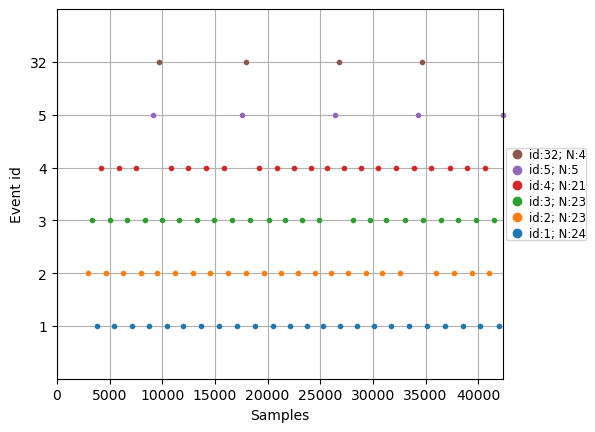

In [5]:
mne.viz.plot_events(events[:100], first_samp=25000);

**Exercise**: Plot the next 100 entries in `events` and set `first_samp=65000`.

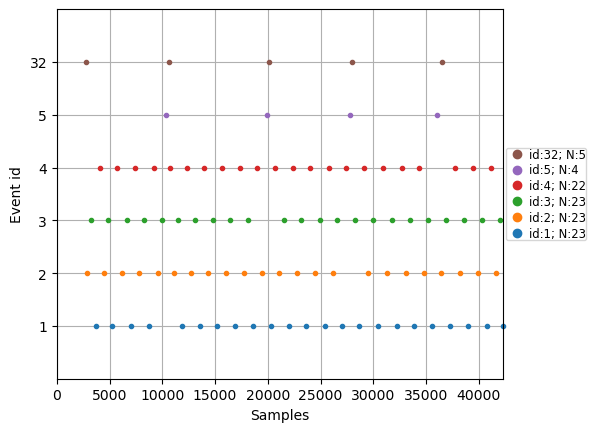

In [6]:
mne.viz.plot_events(events[100:200], first_samp=65000);

The events are encoded as integer numbers, but we can attach labels to them to describe the actual event that is represented by each number. The dictionary `event_id` contains descriptions of the different events in our data.

In [7]:
event_id = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "face": 5,
    "button": 32,
}

**Exercise**: Plot the first 100 entries in `events` again but set `event_id=event_id` to display the event description in the legend. Can you guess from the plot what the `"button"` event corresponds to?

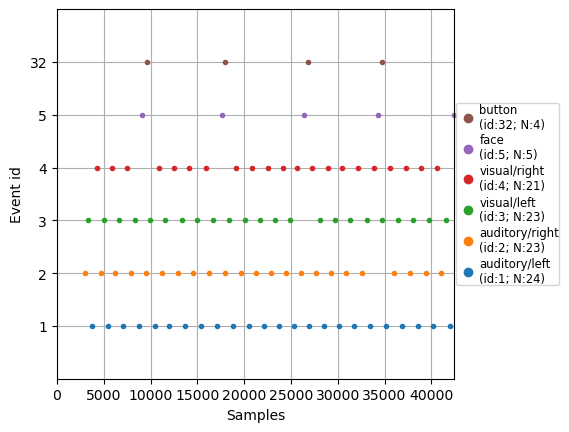

In [8]:
mne.viz.plot_events(events[:100], first_samp=25000, event_id=event_id);

**Example**: Merge the events `3` and `4` (i.e. the left and right visual stimuli), encode the merged event with the number `34` and overwrite the existing `events`.

In [9]:
events = mne.merge_events(events, ids=[3,4], new_id=34)

**Exercise**: Merge the events `1` and `2` (i.e. the left and right auditory stimuli), encode the merged event with the number `12` and overwrite the existing `events`.

In [10]:
events = mne.merge_events(events, ids=[1,2], new_id=12)

**Exercise**: Create a new `event_id` dictionary with the keys `"auditory"` and `"visual"` mapped to the merged event codes `12` and `34`.

In [11]:
event_id = {
    "auditory": 12,
    "visual": 34,
    "face": 5,
    "button": 32,
}

**Exercise**: Plot the first 50 entries in `events` with the new `event_id`.

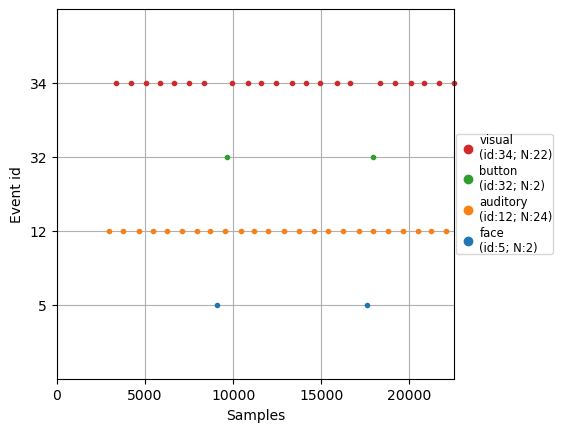

In [12]:
mne.viz.plot_events(events[:50], first_samp=25000, event_id=event_id);

## Epoching Continuous EEG Data

### Background

Once the events have been identified, the continuous EEG recording can be cut into short segments called **epochs**, each time-locked to an event of interest. `mne.Epochs` takes the raw data, the events array, the `event_id` dictionary, and the desired time window around each event. Specific event types can be selected by indexing the `Epochs` object with a key from `event_id` (e.g. `epochs["auditory"]`). Averaging all epochs of the same type cancels out the random background noise and reveals the **event-related potential (ERP)** — the consistent, time-locked brain response.

**Baseline correction** removes slow amplitude drifts by subtracting the mean amplitude during a pre-stimulus reference period from the entire epoch. By default, MNE uses the interval from the start of the epoch to the event onset (time 0) as the baseline. Choosing an appropriate baseline is important: if the baseline interval contains event-related activity, it will be subtracted from the rest of the signal, introducing spurious features into the ERP.

### Exercises

In the following exercises, you are going to compute epochs from the continuous raw EEG data, average them and visualize the ERP for different stimulus conditions. You are also going to play with the `baseline` argument to explore how selecting a baseline interval affects the resulting ERP. Here are the code snippets you'll need:

| Code | Description |
| --- | --- |
| `epochs = mne.Epochs(raw, events, event_id, tmin=-0.3, tmax=1)` | Divide the `raw` data into epochs from `-0.3` to `1` seconds relative to the `events` |
| `epochs = mne.Epochs(raw, events, event_id, tmin=-0.3, tmax=1, baseline=(-0.1, 0))` | Divide the `raw` data into epochs and use the interval from `-0.1` to `0` seconds as `baseline` |
| `epochs = mne.Epochs(raw, events, event_id, tmin=-0.3, tmax=1, baseline=None)` | Divide the `raw` data into epochs without baseline correction |
| `epochs.plot()` | Plot the epoched data |
| `epochs["event"].average().plot()` | Average all epochs for `"event"` and plot the ERP |

**Example**: Slice the `raw` data into `Epochs` from `-0.3` to `1.0` seconds relative to every event in `events` and plot the first 5 epochs.

In [13]:
epochs = mne.epochs.Epochs(raw, events, event_id=event_id, tmin=-0.3, tmax=1.0)
epochs.plot(n_epochs=5);

Not setting metadata
320 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 320 events and 782 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 5 events and 782 original time points ...
Using data from preloaded Raw for 5 events and 782 original time points ...
Using data from preloaded Raw for 32 events and 782 original time points ...


**Exercise**: Slice the `raw` data into `Epochs` from `-0.1` to `0.6` seconds relative to every event in `events` and plot the first 5 epochs.

In [14]:
epochs = mne.epochs.Epochs(raw, events, event_id=event_id, tmin=-0.1, tmax=0.6)
epochs.plot(n_epochs=5);

**Example**: Average all `"visual"` epochs and `.plot()` the ERP. The colors represent the channel locations, shown on the scalp map in the top left corner of the plot.

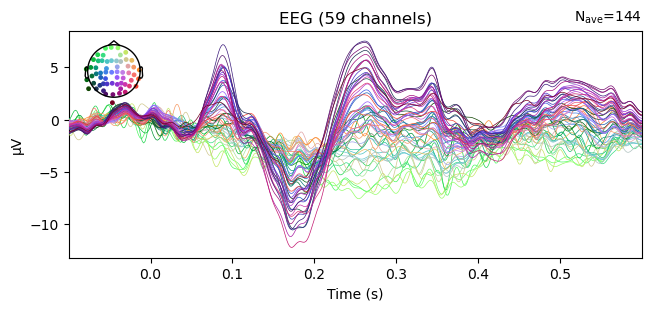

In [15]:
erp = epochs["visual"].average()
erp.plot();

**Exercise**: Average all `"auditory"` epochs and `.plot()` the ERP.

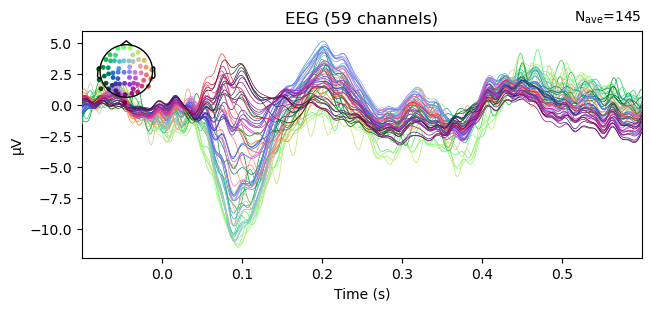

In [16]:
erp = epochs["auditory"].average()
erp.plot();

**Exercise**: Average all `"face"` epochs and `.plot()` the ERP. Why is this average noisier than the previous ones?

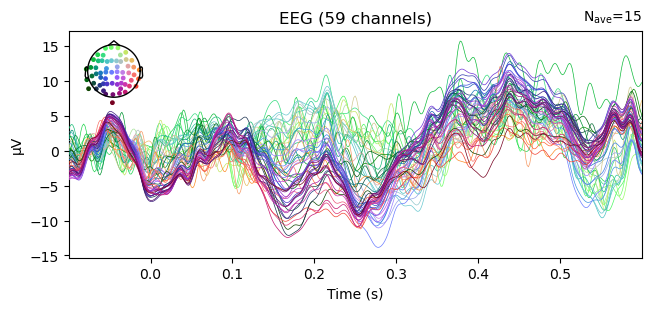

In [17]:
erp = epochs["face"].average()
erp.plot();

**Example**: By default, MNE uses the interval before the event as a `baseline` period and subtracts it from the rest of the signal. Re-create the `Epochs` but explicitly set the `baseline` to the interval `(-0.1, 0)` and plot the `"auditory"` ERP.

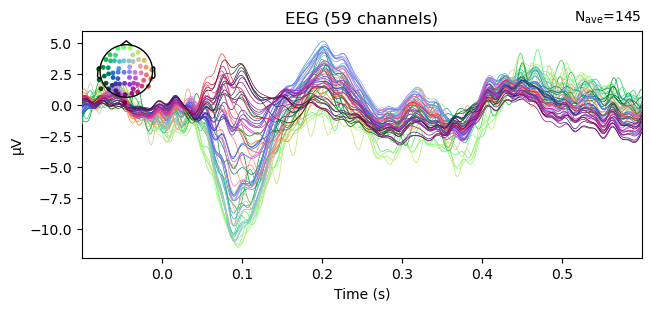

In [18]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.6, baseline=(-0.1, 0))
erp = epochs["auditory"].average()
erp.plot();

**Exercise**: Baseline correction can lead to spurious features because activity in the baseline period can be projected into the rest of the signal. To see what happens when the baseline contains event-related activity, re-create the `Epochs` and set the `baseline` interval to `(0.05, 0.15)`. Then, plot the `"auditory"` ERP again.

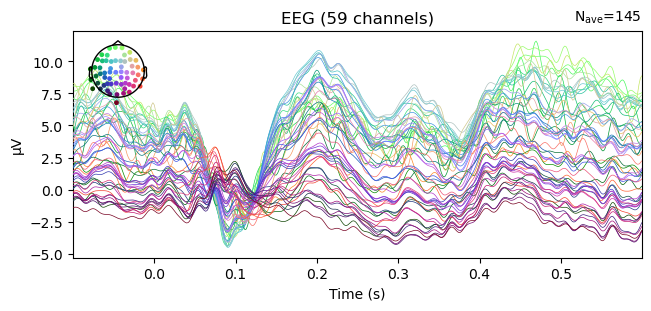

In [19]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.6, baseline=(0.05, 0.15))
erp = epochs["auditory"].average()
erp.plot();

**Exercise**: It's usually a good idea to check how the data looks without a baseline. Re-create the `Epochs` and set the `baseline` argument to `None`. Then, plot the `"auditory"` ERP again.

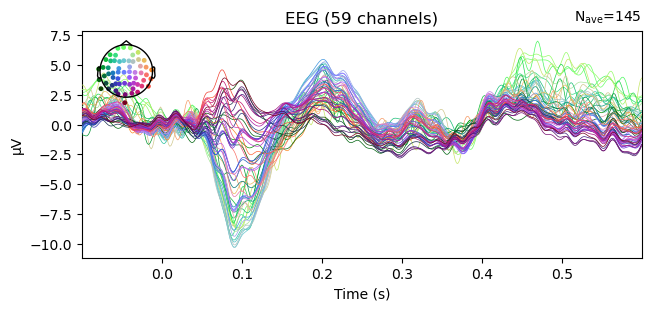

In [20]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.6, baseline=None)
erp = epochs["auditory"].average()
erp.plot();

## Re-Referencing EEG Recordings

### Background

All EEG measurements are potential differences between two points: the active electrode and a **reference electrode**. The choice of reference affects the amplitude and topography of the ERP — not because the underlying brain activity changes, but because all voltages are expressed relative to a different point. A useful analogy is a landscape of hills and valleys: the terrain does not change, but every elevation value changes depending on where you set the zero level.

Common reference choices include:
- **Single electrode** (e.g. a mastoid or vertex electrode): simple and reproducible, but biased by the activity of that channel
- **Linked mastoids** (average of left and right mastoid electrodes): commonly used in auditory research, reduces the bias of a single reference
- **Average reference** (mean of all electrodes): considered the most unbiased choice for dense arrays, as no single electrode dominates

### Exercises

In this section, you are going to learn how to change the reference electrode using the `.set_eeg_reference()` method. To visualize the effect of different references, you are going to use the `.plot_joint()` method which combines the ERP time course with topographical maps that are great for visualizing the distribution of voltage across the scalp. Here are the relevant code snippets:

| Code | Description |
| --- | --- |
| `epochs["event"].average().plot_joint()` | Average all epochs for `"event"` and create a joint ERP and topography plot |
| `epochs["event"].average().plot_joint(times=[0.1, 0.2])` | Same, but show topographies at `0.1` and `0.2` seconds |
| `epochs.set_eeg_reference("average")` | Set the reference to the average of all channels |
| `epochs.set_eeg_reference(["EEG 001"])` | Set the reference to channel `"EEG 001"` |
| `epochs.set_eeg_reference(["EEG 001", "EEG 002"])` | Set the reference to the average of `"EEG 001"` and `"EEG 002"` |

Run the cell below to re-create the `Epochs` between `-0.1` and `0.5` seconds without a baseline.

In [21]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.5, baseline=None, preload=True)

**Example**: Compute the `"auditory"` ERP and use the `.plot_joint()` method to visualize it along with the topographical distribution of voltage at `[0.095, 0.2]` seconds.

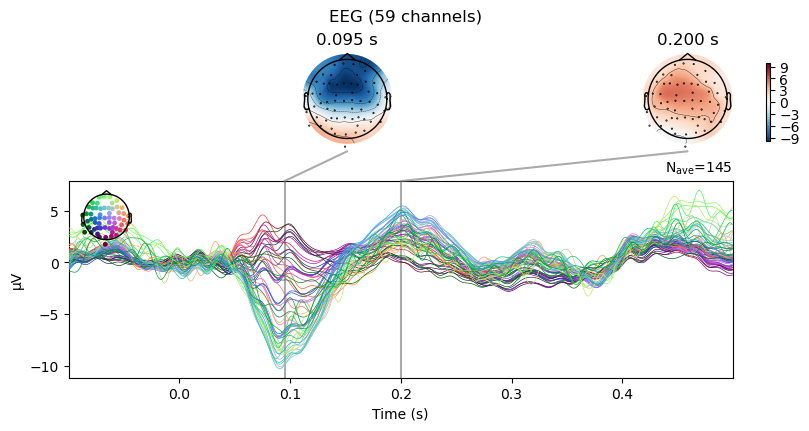

In [22]:
erp = epochs["auditory"].average()
erp.plot_joint(times=[0.095, 0.2]);

**Exercise**: Compute the `"visual"` ERP and use the `.plot_joint()` method to visualize it along with the topographical distribution of voltage at `[0.09, 0.18, 0.26]` seconds.

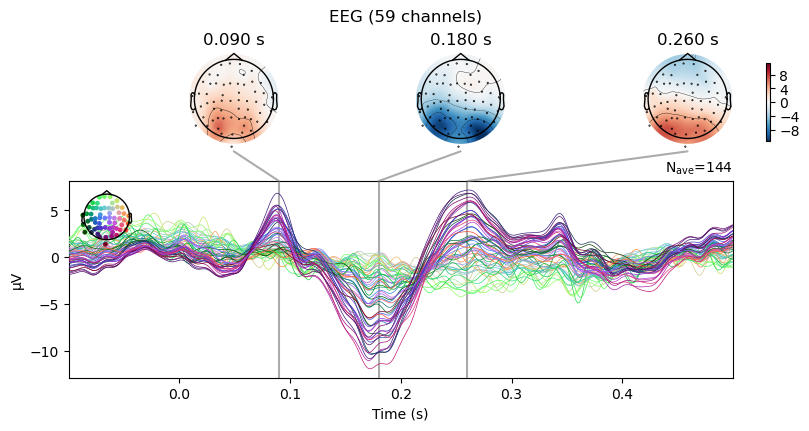

In [23]:
erp = epochs["visual"].average()
erp.plot_joint(times=[0.09, 0.18, 0.26]);

**Exercise**: Use `.set_eeg_reference()` to reference the recording to the `"average"` of all channels. Then, re-compute the ERP and visualize it with `.plot_joint()` using the same `times` as before. Compare the topographical voltage distributions to the previous plot.

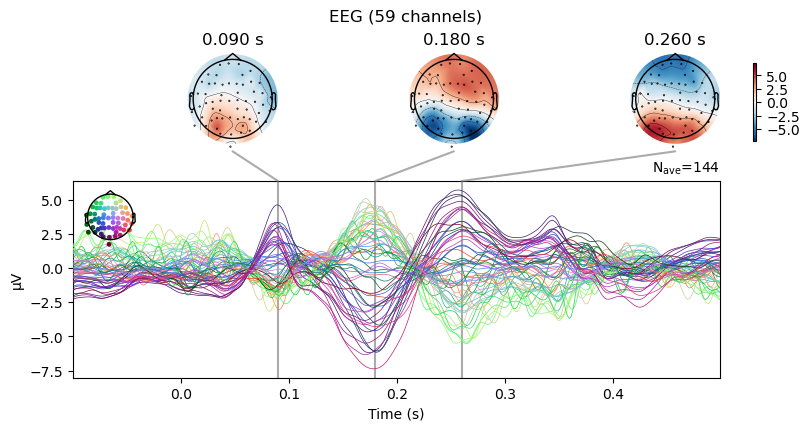

In [24]:
epochs.set_eeg_reference("average")
erp = epochs["visual"].average()
erp.plot_joint(times=[0.09, 0.18, 0.26]);

**Exercise**: Use `.set_eeg_reference()` to reference the recording to the occipital channel `"EEG 060"`. Then, re-compute the ERP and visualize it with `.plot_joint()` using the same `times` as before. Compare the topographical voltage distributions to the previous plot.

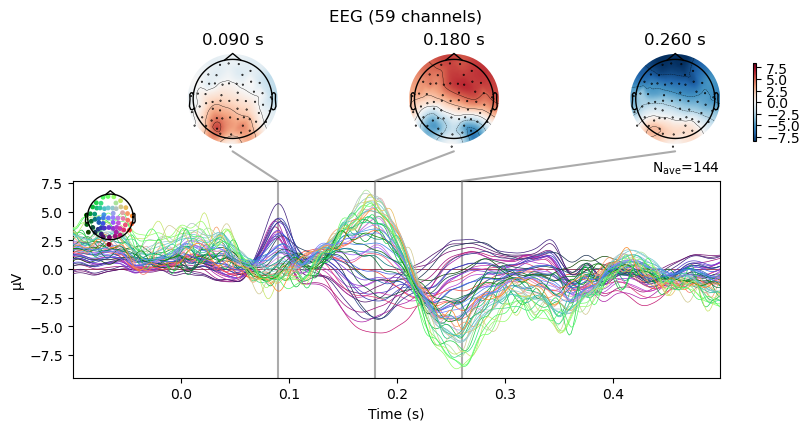

In [25]:
epochs.set_eeg_reference(["EEG 060"])
erp = epochs["visual"].average()
erp.plot_joint(times=[0.09, 0.18, 0.26]);

**Exercise**: Use `.set_eeg_reference()` to reference the recording to the average of the lateral channels `["EEG 017", "EEG 024"]`. Then, re-compute the ERP and visualize it with `.plot_joint()` using the same `times` as before.

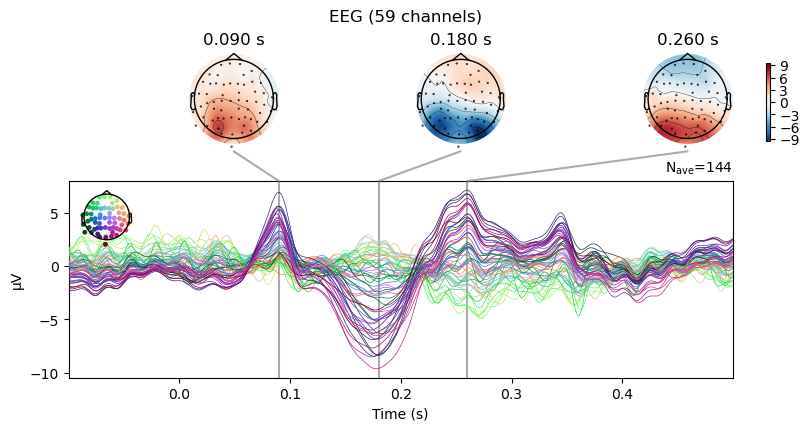

In [26]:
epochs.set_eeg_reference(["EEG 017", "EEG 024"])
erp = epochs["visual"].average()
erp.plot_joint(times=[0.09, 0.18, 0.26]);

**Exercise**: Run the cell below to plot all EEG sensors with their names. Select a channel or a combination of channels, set them as the reference and visualize the ERP with `.plot_joint()`. Try to anticipate how the plot will look (for example, you could choose the channel with the largest amplitude as reference).

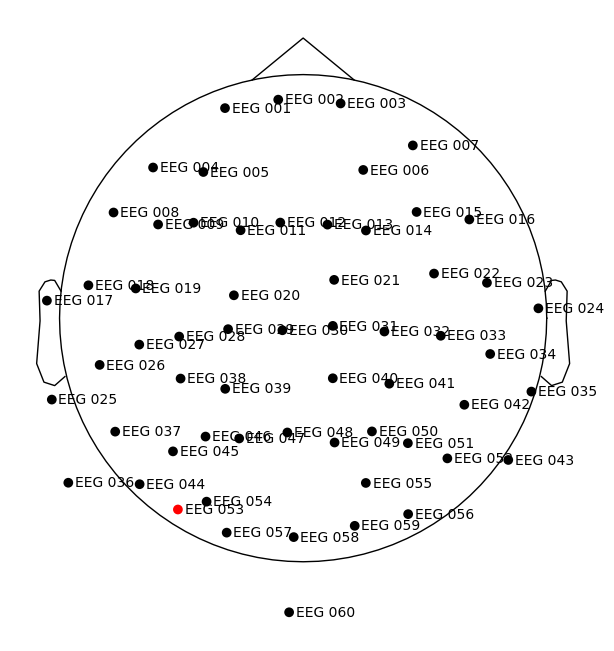

In [27]:
epochs.plot_sensors(show_names=True);

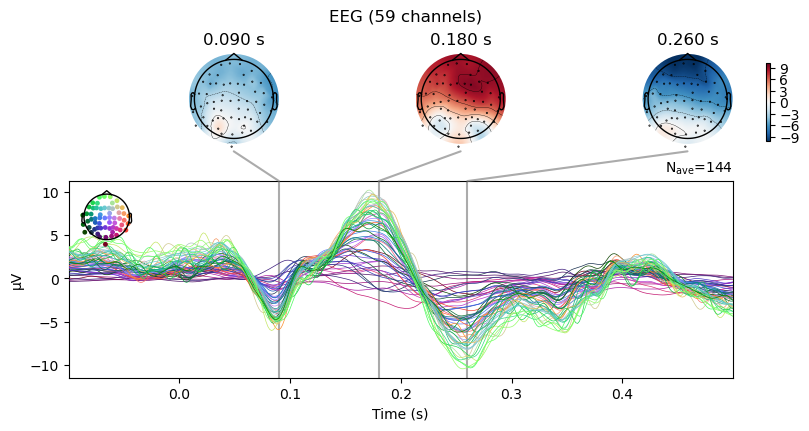

In [28]:
epochs.set_eeg_reference(["EEG 057", "EEG 059"])
erp = epochs["visual"].average()
erp.plot_joint(times=[0.09, 0.18, 0.26]);

## Finding and Rejecting Bad Epochs

### Background

EEG recordings inevitably contain epochs contaminated by artifacts — large-amplitude deflections caused by muscle activity, eye blinks, electrode pops, or other non-neural sources. Including these outlier epochs in the average distorts the ERP and should be avoided. The most common approach is **amplitude-based rejection**: epochs where any channel exceeds a peak-to-peak amplitude threshold are discarded. The threshold must be chosen carefully — too strict and you lose too many epochs (reducing the signal-to-noise ratio), too lenient and artifacts remain.

A related issue is **bad channels** — channels that produce consistently noisy data due to poor contact or hardware problems. Rather than losing many epochs because of a single problematic channel, it is better to mark it as bad and ignore it when dropping epochs based on an amplitude threshold.

### Exercises

| Code | Description |
| --- | --- |
| `epochs["event"].plot_image(combine="mean")` | Plot all epochs for `"event"` as an image, showing the mean across channels |
| `epochs_clean = epochs.copy()` | Create a copy of `epochs` |
| `epochs_clean.drop_bad(reject={"eeg": 100e-6})` | Drop epochs where any channel exceeds `100` µV peak-to-peak amplitude |
| `epochs_clean.plot_drop_log()` | Plot which epochs were dropped and which channels caused the rejection |
| `epochs.info["bads"].append("EEG 001")` | Mark `"EEG 001"` as a bad channel |

Run the cell below to re-create the `Epochs` from `-0.1` to `0.5` seconds without `baseline` correction, referenced to channels `["EEG 057", "EEG 059"]`.

In [29]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.5, preload=True, baseline=None)
epochs.set_eeg_reference(["EEG 057", "EEG 059"]);

**Example**: Plot all `"visual"` epochs as an image. In the top panel, every row in the image represents a single epoch. The bottom panel shows the mean across channels averaged across all epochs. Can you spot outlier epochs where the amplitude is particularly high?

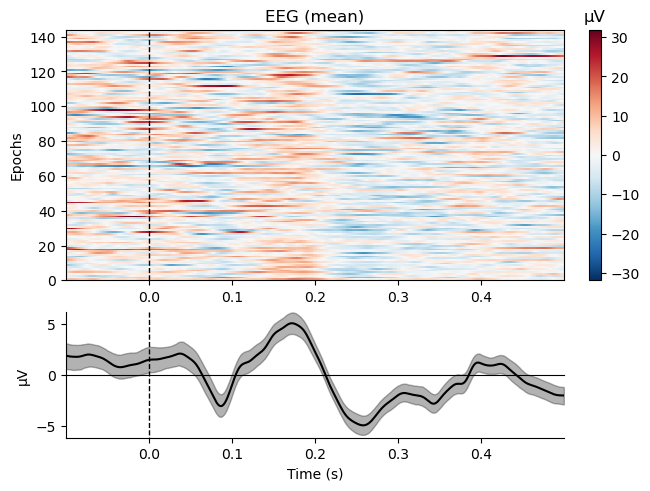

In [30]:
epochs["visual"].plot_image(combine="mean");

**Exercise**: Plot all `"auditory"` epochs as an image.

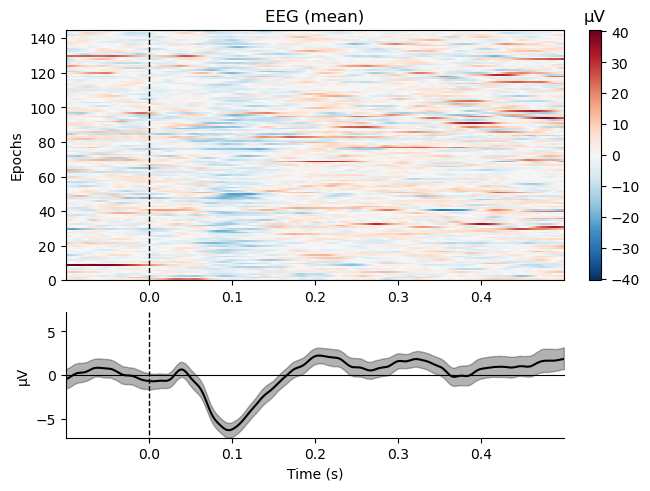

In [31]:
epochs["auditory"].plot_image(combine="mean");

**Example**: To remove outlier epochs, define a dictionary of `reject_criteria` to reject epochs with a peak-to-peak amplitude above $150\mu V$ (i.e. `150e-6` $V$). Then, copy the `epochs`, apply the rejection criteria and use `.plot_drop_log()` to see which channels are responsible for the dropped epochs.

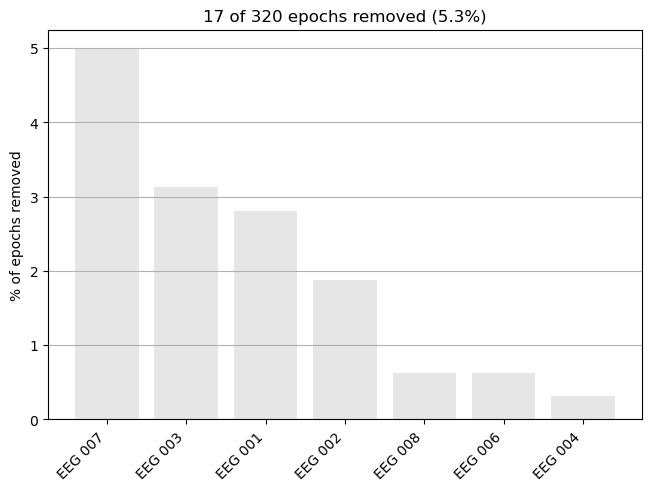

In [32]:
reject_criteria = {"eeg":150e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Exercise**: Define a new dictionary of `reject_criteria` to reject epochs with a peak-to-peak amplitude above $90\mu V$, apply it to a copy of `epochs` and plot the drop log.

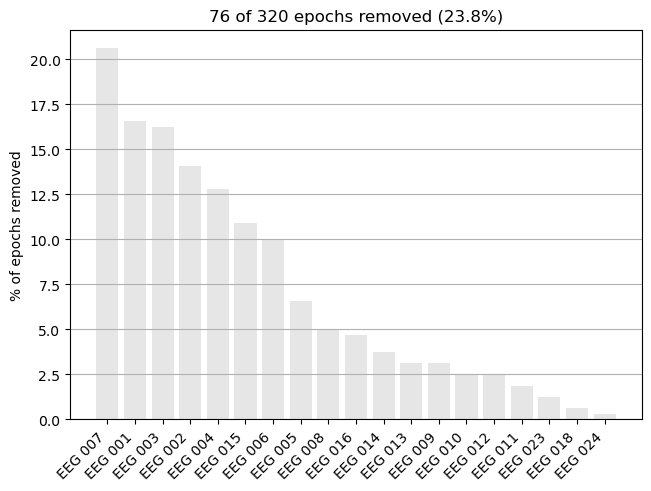

In [33]:
reject_criteria = {"eeg":90e-6}
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

**Exercise**: Plot all `"visual"` trials as an image using the cleaned epochs. You should see fewer outliers and a cleaner average compared to the previous image plot.

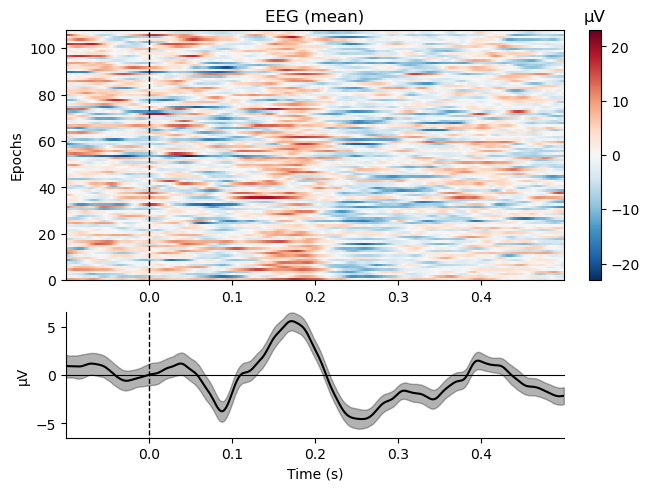

In [34]:
epochs_clean["visual"].plot_image(combine="mean");

**Exercise**: It seems that the channel `"EEG 007"` is involved in the largest number of dropped epochs. Add it to the list of bad channels to make `.drop_bad()` ignore it. Then, apply the same rejection criterion as before and compare the drop log to the previous exercise.

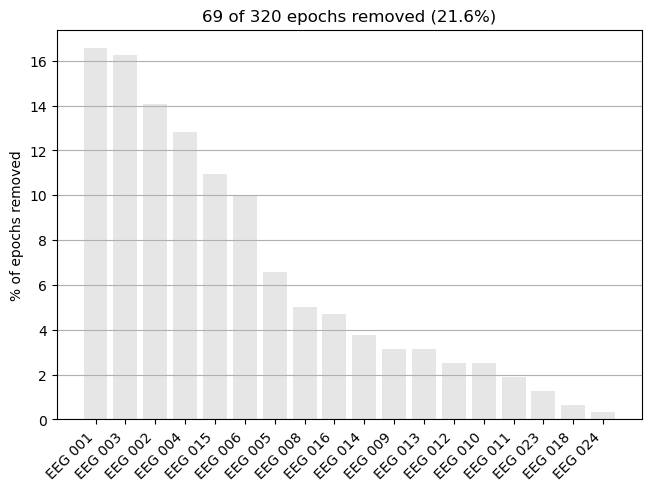

In [35]:
epochs.info["bads"].append("EEG 007")
epochs_clean=epochs.copy()
epochs_clean.drop_bad(reject=reject_criteria, verbose=False)
epochs_clean.plot_drop_log();

## Automated Rejection of Bad Epochs

### Background

As we saw in the previous section, certain channels are noisier than others, making it hard to find a rejection threshold that works across all channels. [Autoreject](https://autoreject.github.io/) (Jas et al., 2017) solves this by automatically estimating the optimal threshold for each channel individually using **cross-validation**: the data is split into folds, and candidate thresholds are scored by how well the cleaned epochs from one fold can predict the held-out epochs (using RMSE). Bayesian optimization is used to search the threshold space efficiently.

For each epoch, autoreject builds an indicator matrix of which channels exceed their threshold. If the number of bad channels is at most the interpolation limit $\rho$, those channels are **interpolated** from their neighbors. If more channels are bad, the **entire epoch is rejected**. This local repair strategy preserves more data than simple global rejection while still removing the most severely contaminated epochs.

> Jas, M., Engemann, D. A., Bekhti, Y., Raimondo, F., & Gramfort, A. (2017). Autoreject: Automated artifact rejection for MEG and EEG data. *NeuroImage*, 159, 417–429.

### Demo

The Autoreject algorithm has to try out many different rejection threshold values, which makes it computationally expensive. To reduce the computational cost, we can reduce the data's sampling rate by using the `decim` parameter of the `Epochs` class. Here, setting `decim=4` will only keep every 4th sample, reducing the sampling rate from 600 Hz to 150 Hz. Also, we'll only focus on the `"auditory"` epochs.

In [36]:
epochs = mne.epochs.Epochs(raw, events, event_id, tmin=-0.1, tmax=0.5, preload=True, baseline=None, decim=4)
epochs = epochs["auditory"]

First, we import the module and create an instance of the `AutoReject` class. Then we apply the `.fit_transform()` method to our `epochs` which finds and applies channel-specific rejection thresholds. This method returns a cleaned version of the epochs as well as a rejection log if `return_log=True`. This may take a while ...

In [38]:
from autoreject import AutoReject

ar = AutoReject()
epochs_clean, reject_log = ar.fit_transform(epochs, return_log=True)

c:\Users\olebi\Projects\EEG-Course\.pixi\envs\default\Lib\site-packages\autoreject\utils.py:73: UserWarning: 1 channels are marked as bad. These will be ignored. If you want them to be considered by autoreject please remove them from epochs.info["bads"].
  warnings.warn(


Running autoreject on ch_type=eeg




Estimated consensus=0.60 and n_interpolate=32


c:\Users\olebi\Projects\EEG-Course\.pixi\envs\default\Lib\site-packages\autoreject\utils.py:73: UserWarning: 1 channels are marked as bad. These will be ignored. If you want them to be considered by autoreject please remove them from epochs.info["bads"].
  warnings.warn(


The drop log shows us what the algorithm actually did. Each row is one channel and each column is one epoch. Channels marked blue have been interpolated in the given epoch, and epochs marked red have been dropped.

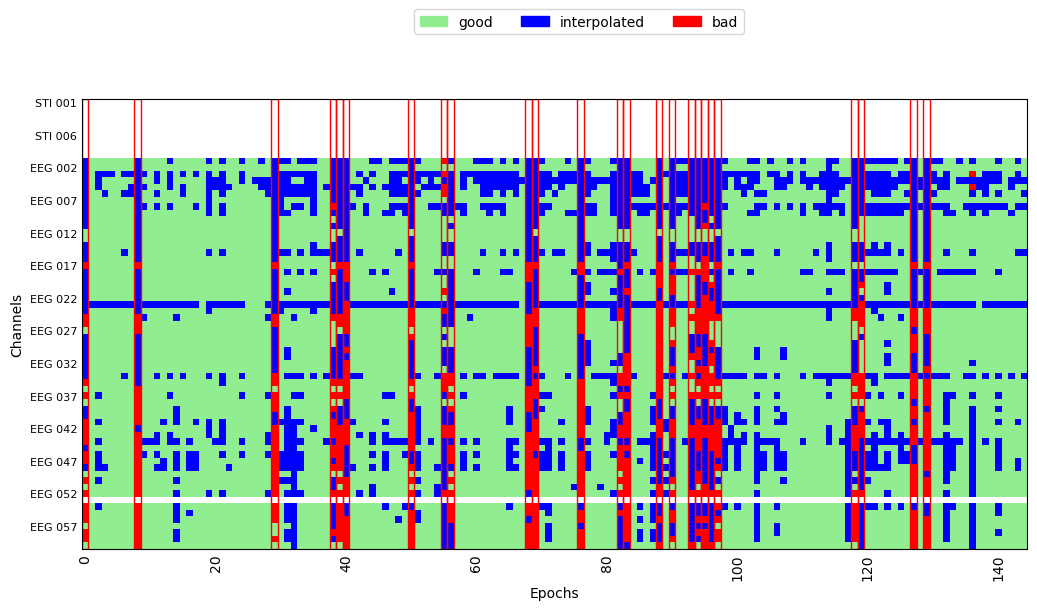

In [39]:
reject_log.plot(orientation='horizontal');

We can also plot the distribution of channel rejection thresholds. Most channels cluster around the same value, but there are a few channels with particularly high thresholds.

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\olebi\AppData\Local\Temp\ipykernel_30744\1882384317.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Threshold ($\mu V$)')


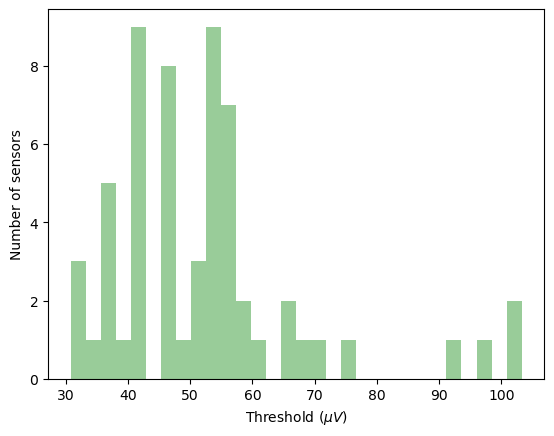

In [40]:
plt.hist(1e6 * np.array(list(ar.threshes_.values())), 30,
         color='g', alpha=0.4)
plt.xlabel('Threshold ($\mu V$)')
plt.ylabel('Number of sensors')
plt.show()